# NB 11c — PCA on a configurable channel subset (Kaggle PUBLIC champion)

Default config: channels 41-46 → **Kaggle public 0.897 / private 0.887** — highest
public-leaderboard score. The private leaderboard is owned by **NB 11d** (hybrid
PCA + env-zscore, private 0.915). The FE artefact (`models/pca_fe_46ch.pkl`) comes
from **NB 11e** (wide-channel detrended PCA).

## What you can configure
- **Channels** — explicit list (default), or load from a CSV (commented).
- **Data source** — `"kaggle"` (use the Kaggle-aligned `train_full_scaled.npy` + boundaries) or `"bootcamp"` (the original 70/15/15 carved arrays in `data/processed/`).
- **Fit pool size** — last `FIT_SIZE` nominal windows (tail-fit) — the tail-fit is what made the difference vs random subsample.

## Where this fits in the family

| Notebook | Variant                              | Kaggle pub | Kaggle priv | Role                          |
|----------|--------------------------------------|-----------:|------------:|-------------------------------|
| **11c**  | 6 ch (41-46)                         |  **0.897** |       0.887 | Public-leaderboard champion   |
| 11d      | hybrid PCA(41-46) + env-zscore       |      0.867 |   **0.915** | Private-leaderboard champion  |
| 11e      | wide-channel detrended PCA (49 / 46) |      0.868 |       0.853 | Source of the FE 46ch artefact|

## 1 - Setup

In [29]:
%load_ext autoreload
%autoreload 2

import sys, time, pickle
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
for p in (PROJECT_ROOT / 'src', PROJECT_ROOT):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from sentinel.params import (
    PROCESSED_DIR, MODELS_DIR,
    RANDOM_STATE, WINDOW_SIZE,
    ANOMALY_COLOR, NOMINAL_COLOR,
)
from sentinel.ml_logic.scorer     import score_windows, score_windows_detrended
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import event_f05, corrected_event_f05, row_precision_recall
from sentinel.ml_logic.data       import find_anomaly_segments
from sentinel.ml_logic.viz        import plot_timeline, plot_event_analysis

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

KAGGLE_DIR  = PROCESSED_DIR / 'kaggle'
SUBS_DIR    = PROJECT_ROOT / 'kaggle' / 'submissions'
SUBS_DIR.mkdir(parents=True, exist_ok=True)
FIT_SIZE    = 50_000
DETREND_WIN = 1000

print(f'KAGGLE_DIR  : {KAGGLE_DIR}')
print(f'WINDOW_SIZE : {WINDOW_SIZE}   FIT_SIZE: {FIT_SIZE:,}')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
KAGGLE_DIR  : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/processed/kaggle
WINDOW_SIZE : 100   FIT_SIZE: 50,000


## 2 - Channel selection 

Two ways to pick the channel subset - the explicit list is the default; uncomment the CSV path
if you'd rather load it from disk.

In [30]:
# ── Option A: explicit list (default - current Kaggle champion) ──────────────
CH_NAMES = [f'channel_{i}' for i in range(41, 47)]   # channel_41..46

# ── Option B: load from CSV (auskommentiert) ────────────────────────────────
# CH_CSV   = PROCESSED_DIR / 'selected_channels.csv'
# CH_NAMES = pd.read_csv(CH_CSV)['channel'].tolist()

# Resolve indices into the 58-column target_channels order used by all preprocessed arrays.
_TARGET_CH = pd.read_csv('../data/raw/target_channels.csv')['target_channels'].tolist()
missing    = [c for c in CH_NAMES if c not in _TARGET_CH]
assert not missing, f'These channels are not in target_channels.csv: {missing}'
CH_INDICES = np.array([_TARGET_CH.index(n) for n in CH_NAMES])
N_FEAT_SUB = len(CH_INDICES)

print(f'channels    : {CH_NAMES}')
print(f'idx in 58   : {CH_INDICES.tolist()}')
print(f'N_FEAT_SUB  : {N_FEAT_SUB}')


channels    : ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']
idx in 58   : [29, 30, 31, 32, 33, 34]
N_FEAT_SUB  : 6


## 3 - Data source 

- `"kaggle"`   - load `data/processed/kaggle/*` and carve val/test from `train_full_scaled` at the same boundaries as NB 11b (`TRAIN_END=10.7M`, `VAL_END=12.7M`).  Submission writes to `kaggle/submissions/`.
- `"bootcamp"` - load the original 70/15/15 split files (`val_scaled.npy`, `test_intern_scaled.npy`) from `data/processed/`. No Kaggle submission alignment in this mode.

In [31]:
DATA_SOURCE = 'kaggle'    # 'kaggle' | 'bootcamp'

if DATA_SOURCE == 'kaggle':
    # Tail-fit pool: last 50k nominal windows of the train portion of train_full
    X_train_full      = np.load(KAGGLE_DIR / 'X_train_full.npy')[..., CH_INDICES]
    y_train_full      = np.load(KAGGLE_DIR / 'y_train_full.npy')
    train_scaled_full = np.load(KAGGLE_DIR / 'train_full_scaled.npy', mmap_mode='r')
    train_scaled      = train_scaled_full[:, CH_INDICES]
    test_scaled       = np.load(KAGGLE_DIR / 'test_scaled.npy')[:, CH_INDICES]
    test_ids          = np.load(KAGGLE_DIR / 'test_ids.npy')
    y_train_row       = np.load(KAGGLE_DIR / 'y_train_row.npy')

    TRAIN_END, VAL_END = 10_700_000, 12_700_000
    VAL_LEN  = VAL_END - TRAIN_END
    TEST_LEN = train_scaled.shape[0] - VAL_END

    X_val           = np.ascontiguousarray(train_scaled[TRAIN_END:VAL_END]).astype(np.float32)
    y_val           = y_train_row[TRAIN_END:VAL_END]
    X_test          = np.ascontiguousarray(train_scaled[VAL_END:]).astype(np.float32)
    y_test          = y_train_row[VAL_END:]
    nominal_mask    = (y_train_full == 0)
    can_submit      = True

elif DATA_SOURCE == 'bootcamp':
    X_train_nom = np.load(PROCESSED_DIR / 'X_train_nom.npy')[..., CH_INDICES]
    val_scaled  = np.load(PROCESSED_DIR / 'val_scaled.npy')[:, CH_INDICES]
    y_val       = np.load(PROCESSED_DIR / 'y_val.npy')
    test_scaled = np.load(PROCESSED_DIR / 'test_intern_scaled.npy')[:, CH_INDICES]
    y_test      = np.load(PROCESSED_DIR / 'y_test_intern.npy')
    test_ids    = None
    test_scaled_kaggle = None

    X_val  = val_scaled.astype(np.float32, copy=False)
    X_test = test_scaled.astype(np.float32, copy=False)
    can_submit = False

else:
    raise ValueError(f'Unknown DATA_SOURCE: {DATA_SOURCE!r}')

print(f'DATA_SOURCE : {DATA_SOURCE}')
print(f'X_val       : {X_val.shape}   anom rows: {int(y_val.sum()):>8,}')
print(f'X_test      : {X_test.shape}   anom rows: {int(y_test.sum()):>8,}')
print(f'Submission  : {"enabled (Kaggle test.parquet)" if can_submit else "disabled (bootcamp split)"}')


DATA_SOURCE : kaggle
X_val       : (2000000, 6)   anom rows:  215,798
X_test      : (2028321, 6)   anom rows:  214,935
Submission  : enabled (Kaggle test.parquet)


## 4 - Fit PCA on the last 50 000 nominal windows

Tail-fit (last 50k nominal windows, *not* a random sample over all of train) - this single
choice was the largest jump in earlier experiments (NB 11b lifted ESA 0.47 → 0.80 vs random fit).

Fitting on 50,000 nominal windows (600 features = WIN×N_FEAT_SUB)
Fit time: 0.2s
k components: 183   cum EV: 0.9502


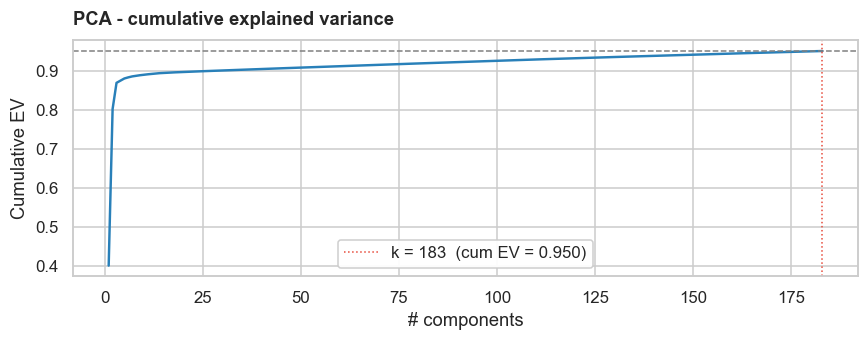

In [32]:
if DATA_SOURCE == 'kaggle':
    # Use the train-portion only (windows whose row span ends ≤ TRAIN_END)
    win_end_row     = (np.arange(len(X_train_full)) + 1) * WINDOW_SIZE
    eligible        = nominal_mask & (win_end_row <= TRAIN_END)
    elig_idx        = np.flatnonzero(eligible)
    fit_idx         = elig_idx[-FIT_SIZE:]
    X_fit           = X_train_full[fit_idx].reshape(len(fit_idx), -1).astype(np.float32)
else:
    fit_idx = np.arange(len(X_train_nom))[-FIT_SIZE:]
    X_fit   = X_train_nom[fit_idx].reshape(len(fit_idx), -1).astype(np.float32)

print(f'Fitting on {len(fit_idx):,} nominal windows '
      f'({X_fit.shape[1]:,} features = WIN×N_FEAT_SUB)')

t0  = time.time()
pca = PCA(n_components=0.95, random_state=RANDOM_STATE).fit(X_fit)
print(f'Fit time: {time.time() - t0:.1f}s')
print(f'k components: {pca.n_components_}   cum EV: {pca.explained_variance_ratio_.sum():.4f}')

# Cumulative EV plot
cum_ev = np.cumsum(pca.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(np.arange(1, len(cum_ev)+1), cum_ev, lw=1.6, color=NOMINAL_COLOR)
ax.axhline(0.95, ls='--', color='grey', lw=1)
ax.axvline(pca.n_components_, ls=':', color=ANOMALY_COLOR, lw=1,
           label=f'k = {pca.n_components_}  (cum EV = {cum_ev[-1]:.3f})')
ax.set_xlabel('# components'); ax.set_ylabel('Cumulative EV')
ax.set_title('PCA - cumulative explained variance', fontweight='bold', loc='left')
ax.legend(); fig.tight_layout(); plt.show()


## 5 - Score val + test

In [33]:
t0 = time.time()
val_scores  = score_windows(pca, X_val,  topk=None)
test_scores = score_windows(pca, X_test, topk=None)
print(f'scoring done in {time.time() - t0:.1f}s')
print(f'val  scores : range [{val_scores.min():.4f}, {val_scores.max():.4f}]   mean {val_scores.mean():.4f}')
print(f'test scores : range [{test_scores.min():.4f}, {test_scores.max():.4f}]   mean {test_scores.mean():.4f}')


scoring done in 0.2s
val  scores : range [0.0114, 30.4105]   mean 0.0233
test scores : range [0.0122, 15.9538]   mean 0.0213


## 6 - Tune threshold on val

Threshold is chosen to maximise `corrected_event_f05` (Pr_ew × TNR) on val - this is
exactly the metric Kaggle uses to score the submission.

In [34]:
tuned     = tune_threshold(val_scores, y_val, metric_fn=corrected_event_f05, n_sweep=80)
threshold = float(tuned['threshold'])
print(f'best threshold: {threshold:.6f}   val corrected_event_f05: {tuned["score"]:.4f}')


best threshold: 0.028049   val corrected_event_f05: 0.8534


## 7 - Metrics summary

All key metrics in one table + bar chart (val vs test). The table starts with **ESA F0.5**
(Kaggle-aligned) and breaks it into its components (event precision Pr_ew and row TNR), followed
by event-wise F0.5 (uncorrected), event recall, row precision/recall/F1, flag rate, and the
**events hit / total** count for both splits.

In [35]:
def compute_metrics(scores, y_true, threshold):
    y_pred = (scores > threshold).astype(np.int8)
    ef     = event_f05(y_true, y_pred)
    esa    = corrected_event_f05(y_true, y_pred)
    rw     = row_precision_recall(y_true, y_pred)
    n_ev_total = int(ef['tp_events'] + ef['fn_events'])
    n_ev_hit   = int(ef['tp_events'])
    return {
        'ESA F0.5 (Kaggle)' : esa['f_score'],
        'Pr_ew (event prec)': esa['precision'],
        'TNR (row spec)'    : esa['tnr'],
        'event F0.5 (raw)'  : ef['f_score'],
        'event recall'      : ef['recall'],
        'event precision'   : ef['precision'],
        'row precision'     : rw['precision'],
        'row recall'        : rw['recall'],
        'row F1'            : rw['f1'],
        'flag rate'         : float(y_pred.mean()),
        'events hit'        : f'{n_ev_hit}/{n_ev_total} ({n_ev_hit / max(n_ev_total,1):.1%})',
        '_n_ev_hit'         : n_ev_hit,
        '_n_ev_total'       : n_ev_total,
        '_y_pred'           : y_pred,
    }

m_val  = compute_metrics(val_scores,  y_val,  threshold)
m_test = compute_metrics(test_scores, y_test, threshold)

# Pretty table
metrics_order = ['ESA F0.5 (Kaggle)', 'Pr_ew (event prec)', 'TNR (row spec)',
                 'event F0.5 (raw)', 'event recall', 'event precision',
                 'row precision', 'row recall', 'row F1', 'flag rate', 'events hit']
df_metrics = pd.DataFrame({
    'Metric': metrics_order,
    'Val'   : [m_val[k]  for k in metrics_order],
    'Test'  : [m_test[k] for k in metrics_order],
})
def _fmt(v):
    if isinstance(v, str): return v
    if isinstance(v, float): return f'{v:.4f}' if abs(v) >= 1e-4 else f'{v:.2e}'
    return str(v)
display_df = df_metrics.copy()
display_df['Val']  = display_df['Val'].map(_fmt)
display_df['Test'] = display_df['Test'].map(_fmt)

print(f'\nThreshold: {threshold:.6f}    DATA_SOURCE={DATA_SOURCE}    channels={CH_NAMES}')
print(display_df.to_string(index=False))



Threshold: 0.028049    DATA_SOURCE=kaggle    channels=['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']
            Metric           Val          Test
 ESA F0.5 (Kaggle)        0.8534        0.8217
Pr_ew (event prec)        0.9995        0.9996
    TNR (row spec)        0.9995        0.9996
  event F0.5 (raw)        0.8537        0.8219
      event recall        0.5385        0.4800
   event precision        1.0000        1.0000
     row precision        0.8327        0.7855
        row recall        0.0201        0.0113
            row F1        0.0392        0.0223
         flag rate        0.0026        0.0015
        events hit 14/26 (53.8%) 12/25 (48.0%)


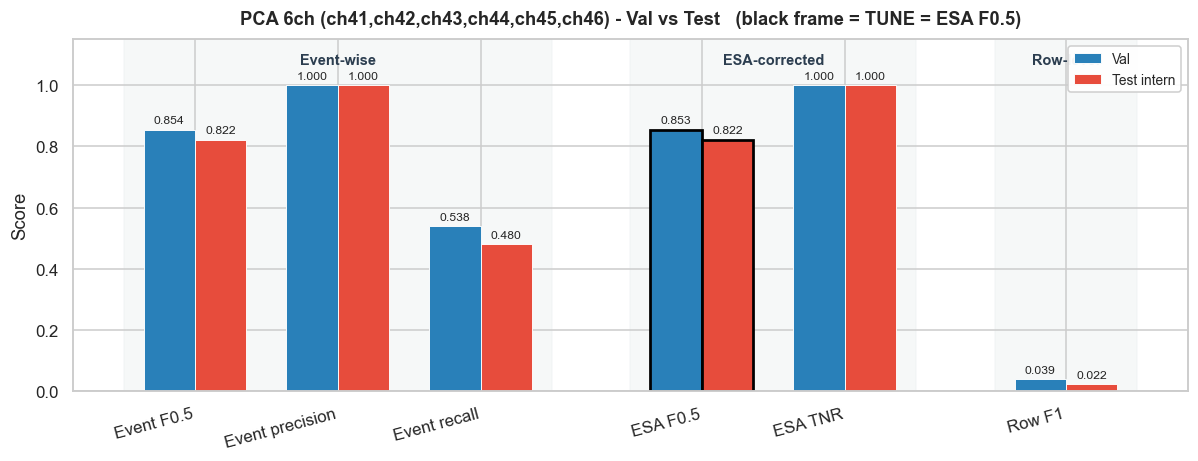

In [36]:
# Headline grouped bar chart - val vs test (nb21 style)
BAR_GROUPS = [
    ('Event-wise',    ['Event F0.5', 'Event precision', 'Event recall']),
    ('ESA-corrected', ['ESA F0.5', 'ESA TNR']),
    ('Row-level',     ['Row F1']),
]
LABEL_TO_KEY = {
    'Event F0.5'     : 'event F0.5 (raw)',
    'Event precision': 'event precision',
    'Event recall'   : 'event recall',
    'ESA F0.5'       : 'ESA F0.5 (Kaggle)',
    'ESA TNR'        : 'TNR (row spec)',
    'Row F1'         : 'row F1',
}
TUNE_LABEL = 'ESA F0.5'   # we tuned the threshold on corrected_event_f05
MODEL_NAME = f"PCA 6ch ({','.join(c.replace('channel_','ch') for c in CH_NAMES)})"

fig, ax = plt.subplots(figsize=(11, 4.3))
w, gap = 0.36, 0.55
xs, xticks, xlabels, band_edges = [], [], [], []
cursor = 0.0
for gname, labels in BAR_GROUPS:
    grp_start = cursor
    for lbl in labels:
        xs.append(cursor); xticks.append(cursor); xlabels.append(lbl)
        cursor += 1.0
    band_edges.append((gname, grp_start - 0.5, cursor - 0.5))
    cursor += gap

xs = np.asarray(xs)
vals_val  = [m_val [LABEL_TO_KEY[l]] for l in xlabels]
vals_test = [m_test[LABEL_TO_KEY[l]] for l in xlabels]
edges = ['black' if l == TUNE_LABEL else 'white' for l in xlabels]
lws   = [1.8     if l == TUNE_LABEL else 0.6     for l in xlabels]

b1 = ax.bar(xs - w/2, vals_val,  w, label='Val',         color=NOMINAL_COLOR, edgecolor=edges, linewidth=lws)
b2 = ax.bar(xs + w/2, vals_test, w, label='Test intern', color=ANOMALY_COLOR, edgecolor=edges, linewidth=lws)
ax.bar_label(b1, fmt='%.3f', fontsize=8, padding=3)
ax.bar_label(b2, fmt='%.3f', fontsize=8, padding=3)

for gname, xlo, xhi in band_edges:
    ax.axvspan(xlo, xhi, color='#ecf0f1', alpha=0.45, zorder=0)
    ax.text((xlo + xhi)/2, 1.06, gname, ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color='#2c3e50')

ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=15, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title(f'{MODEL_NAME} - Val vs Test   (black frame = TUNE = {TUNE_LABEL})', fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
fig.tight_layout(); plt.show()


## 8 - Timeline plots

`plot_timeline` shows the windowed MSE on the upper panel (with the threshold line and shaded
true-anomaly bands) and predicted vs true events on the lower panel (TP / FP, equal panel
heights). Use `log_y=True` so a single large spike doesn't squash everything else.

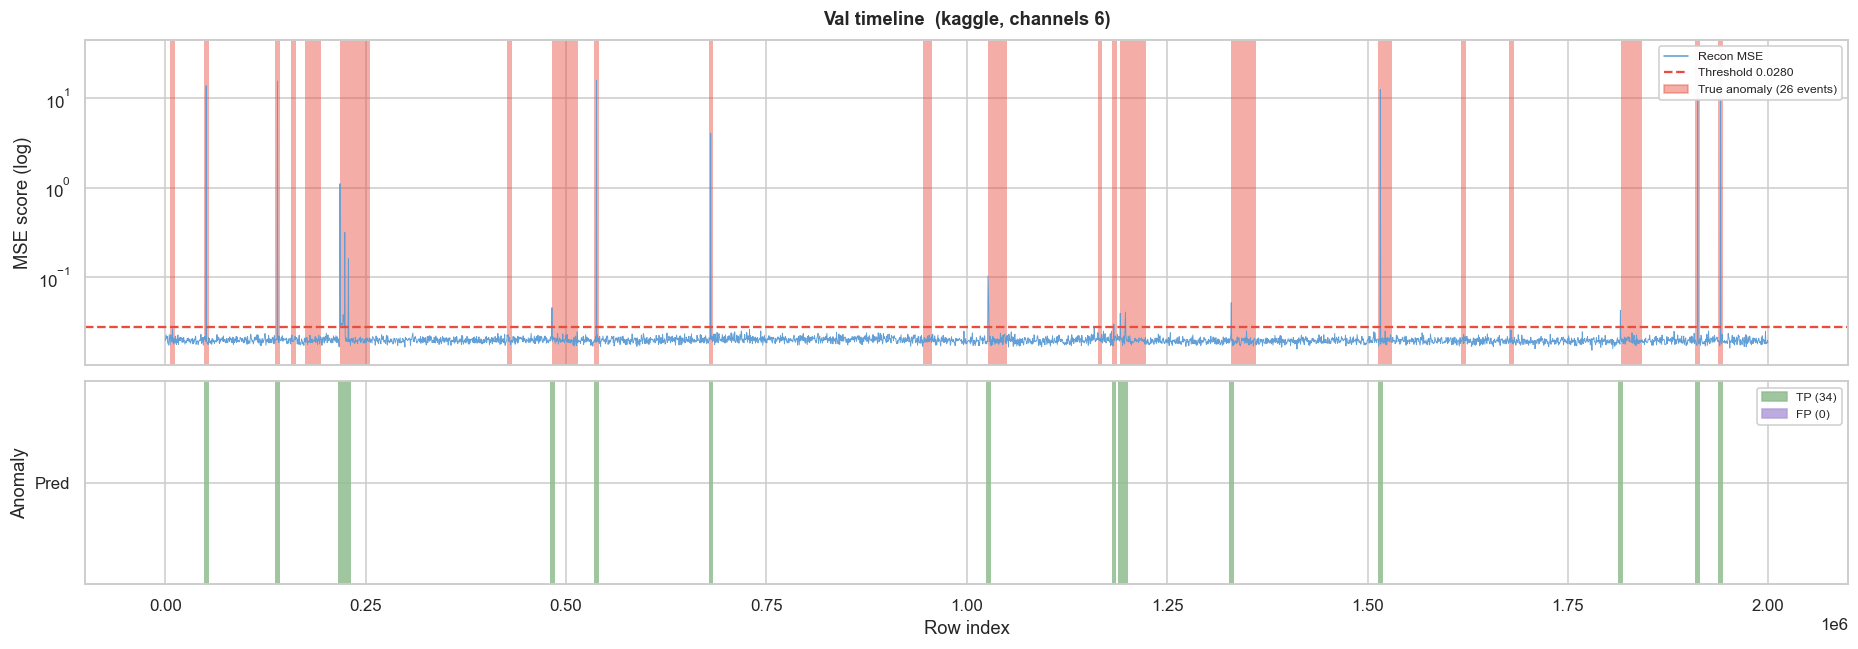

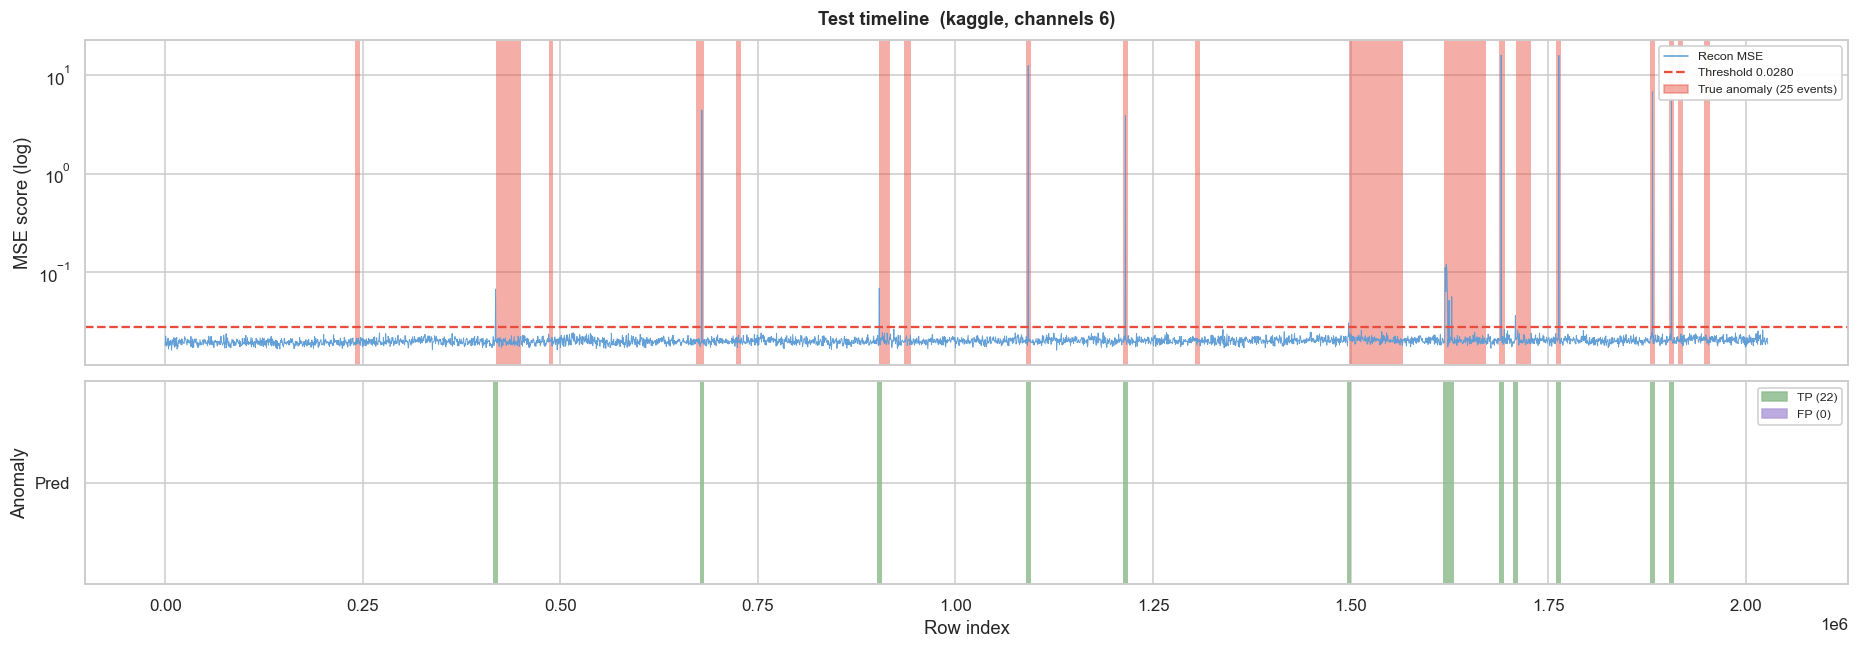

In [37]:
_ = plot_timeline(val_scores,  y_val,  threshold,
                  title=f'Val timeline  ({DATA_SOURCE}, channels {len(CH_INDICES)})',
                  log_y=True)
plt.show()

_ = plot_timeline(test_scores, y_test, threshold,
                  title=f'Test timeline  ({DATA_SOURCE}, channels {len(CH_INDICES)})',
                  log_y=True)
plt.show()


## 9 - Event analysis - detected vs missed

`plot_event_analysis` shows each true event as a horizontal bar (length on log scale,
green = detected, red = missed, hit-rate annotated) plus a length-bucket summary on the right.

Missed events:
  start     end  length
   9219    9587     369
 158321  162679    4359
 174923  193837   18915
 429365  429700     336
 947186  949024    1839
 952299  954134    1836
1165985 1166260     276
1522146 1522332     187
1522643 1523752    1110
1527386 1528051     666
1619693 1619971     279
1679098 1680347    1250


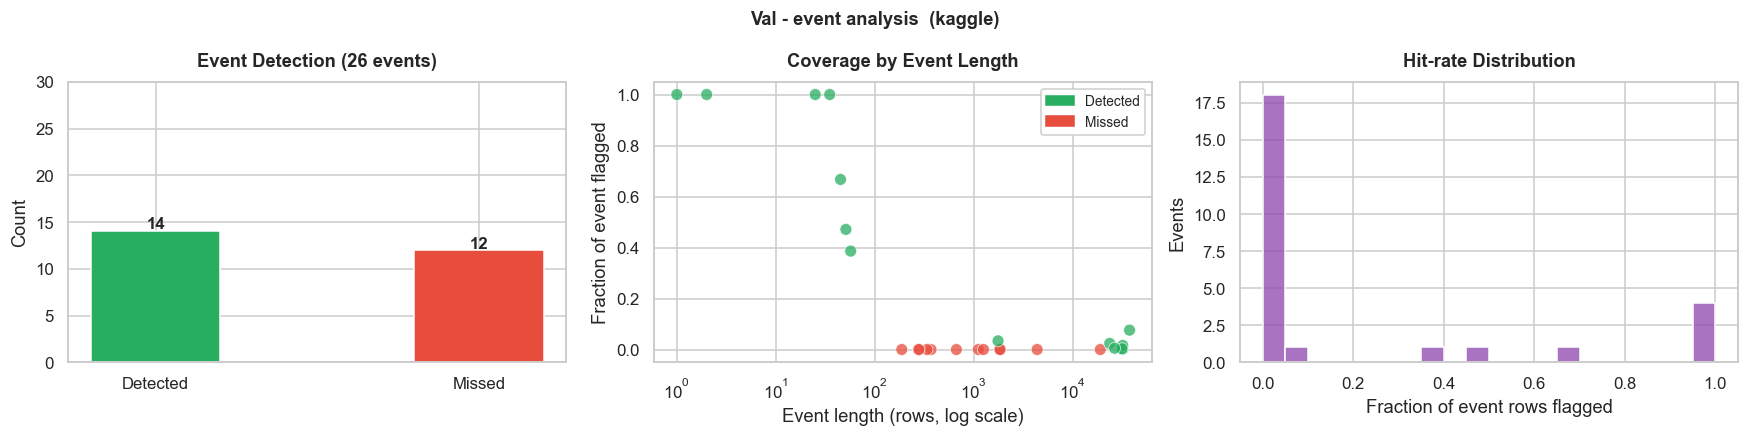

Missed events:
  start     end  length
 242499  243978    1480
 485619  490754    5136
 722632  727323    4692
 937585  937616      32
 938221  938247      27
 939737  939759      23
 940375  940404      30
1305587 1306297     711
1690836 1692821    1986
1916825 1917361     537
1949666 1949668       3
1949681 1949683       3
1949804 1954252    4449


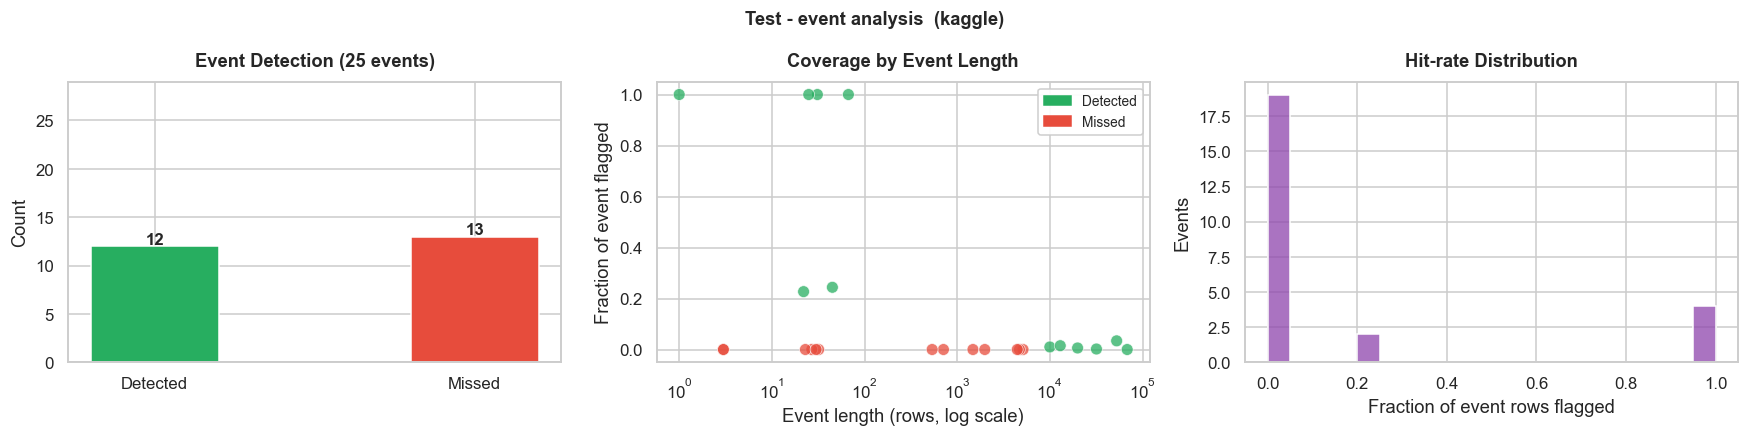

In [38]:
_ = plot_event_analysis(y_val,  m_val['_y_pred'],
                        title=f'Val - event analysis  ({DATA_SOURCE})')
plt.show()

_ = plot_event_analysis(y_test, m_test['_y_pred'],
                        title=f'Test - event analysis  ({DATA_SOURCE})')
plt.show()


## 10 - Save model & Kaggle submission

In [ ]:
def _compact_ch_tag(names):
    """Compact filename tag for channel sets. Range -> 'ch41-46', otherwise 'NNch'."""
    nums = sorted(int(c.replace("channel_", "")) for c in names)
    if nums == list(range(nums[0], nums[-1] + 1)):
        return f"ch{nums[0]}-{nums[-1]}"
    return f"{len(nums)}ch"

# Save model
# MODELS_DIR.mkdir(exist_ok=True)
# ts  = time.strftime('%Y%m%d_%H%M%S')
# tag = _compact_ch_tag(CH_NAMES)
# model_path = MODELS_DIR / f'pca_nb11c_{tag}_{ts}.pkl'
# with open(model_path, 'wb') as f:
#     pickle.dump({'pca': pca, 'channels': CH_NAMES, 'ch_indices': CH_INDICES,
#                  'threshold': threshold, 'data_source': DATA_SOURCE}, f)
# print(f'Model saved → {model_path}')


In [40]:
# Save scores
# SCORES_DIR = PROCESSED_DIR / 'scores'
# SCORES_DIR.mkdir(parents=True, exist_ok=True)
# np.save(SCORES_DIR / 'scores_val_pca_nb11c.npy',  val_scores)
# np.save(SCORES_DIR / 'scores_test_pca_nb11c.npy', test_scores)
# print(f'Scores saved to {SCORES_DIR}')

In [ ]:
# ── Kaggle submission ───────────────────────────────────────────────────
# # Only valid when DATA_SOURCE == 'kaggle' (test_scaled was loaded with the same channel slice)
# assert DATA_SOURCE == 'kaggle' and can_submit, 'Submission only enabled in DATA_SOURCE=kaggle mode'
#
# X_kaggle      = test_scaled.astype(np.float32, copy=False)
# kaggle_scores = score_windows(pca, X_kaggle, topk=None)
# y_kaggle      = (kaggle_scores > threshold).astype(np.uint8)
# print(f'Kaggle scores range : [{kaggle_scores.min():.4f}, {kaggle_scores.max():.4f}]')
# print(f'positive rate       : {y_kaggle.mean():.4%}  ({int(y_kaggle.sum()):,} / {len(y_kaggle):,})')
#
# submission = pd.DataFrame({'id': test_ids, 'is_anomaly': y_kaggle})
# sample_sub = pd.read_parquet('../data/raw/sample_submission.parquet')
# assert list(submission['id']) == list(sample_sub['id']), 'ID mismatch vs sample_submission'
#
# ts  = time.strftime('%Y%m%d_%H%M%S')
# tag = _compact_ch_tag(CH_NAMES)
# submission_path = SUBS_DIR / f'pca_nb11c_{tag}_{ts}.parquet'
# submission.to_parquet(submission_path, index=False)
# print(f'Submission saved → {submission_path}')
